<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/53DecisionTreeAndRandomForestPractice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/Iris.csv')
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
from sklearn.model_selection import train_test_split

In [4]:
X = df.drop(['Species'],axis=1)
y = df['Species']
X_train , X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [5]:
from sklearn.tree import DecisionTreeClassifier

In [6]:
from sklearn.metrics import accuracy_score,precision_score,recall_score

In [7]:
model_1 = DecisionTreeClassifier(max_depth=2)

model_1.fit(X_train,y_train)

# training data accuracy
y_pred_train = model_1.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train,y_pred_train)}")


# testing accuracy
y_pred = model_1.predict(X_test)

print(f"Testing Accuracy: {accuracy_score(y_test,y_pred)}")

Training Accuracy: 1.0
Testing Accuracy: 1.0


In [8]:
model_2 = DecisionTreeClassifier()

model_2.fit(X_train,y_train)

# training data accuracy
y_pred_train = model_2.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train,y_pred_train)}")


# testing accuracy
y_pred = model_2.predict(X_test)

print(f"Testing Accuracy: {accuracy_score(y_test,y_pred)}")

Training Accuracy: 1.0
Testing Accuracy: 1.0


None of them is overfitting or underfitting

In [9]:
df = pd.read_csv('/content/winequality-red.csv')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [10]:
X = df.drop(['quality'],axis=1)
y = df['quality']
X_train , X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [11]:
depth = [2, 4, 6, 8, None]
results = []

In [12]:
for dep in depth:
  model_clf = DecisionTreeClassifier(max_depth = dep, random_state=42)
  model_clf.fit(X_train, y_train)

  train_accuracy = accuracy_score(y_train, model_clf.predict(X_train))
  test_accuracy = accuracy_score(y_test, model_clf.predict(X_test))

  results.append({
      'max_depth': 'None' if dep is None else dep,
      'train_accuracy': round(train_accuracy, 4),
      'test_accuracy': round(test_accuracy, 4)
  })

In [13]:
result_df = pd.DataFrame(results)
print(result_df)

  max_depth  train_accuracy  test_accuracy
0         2          0.5700         0.5125
1         4          0.6302         0.5625
2         6          0.7123         0.5750
3         8          0.8022         0.5813
4      None          1.0000         0.6062


Depth None giving best performance

In [14]:
df = pd.read_csv('/content/data.csv')
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [15]:
df.drop(columns = ['Unnamed: 32'], inplace=True)

In [16]:
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [17]:
X = df.drop(['diagnosis'],axis=1)
y = df['diagnosis']
X_train , X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [19]:
model_1 = DecisionTreeClassifier()

model_1.fit(X_train,y_train)

# testing accuracy
y_pred = model_1.predict(X_test)

accruracy_dt = accuracy_score(y_test,y_pred)
recall_dt = recall_score(y_test, y_pred, pos_label='M')
precision_dt = precision_score(y_test, y_pred, pos_label='M')

In [20]:
from sklearn.ensemble import RandomForestClassifier

In [22]:
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)

accruracy_rf = accuracy_score(y_test,y_pred)
recall_rf = recall_score(y_test, y_pred, pos_label='M')
precision_rf = precision_score(y_test, y_pred, pos_label='M')

In [24]:
comparison_table = []

In [26]:
comparison_table.append({
    'Model': 'Decision Tree',
    'Accuracy': accruracy_dt,
    'Recall': recall_dt,
    'Precision': precision_dt
})

In [27]:
comparison_table.append({
    'Model': 'Random Forest',
    'Accuracy': accruracy_rf,
    'Recall': recall_rf,
    'Precision': precision_rf
})

In [28]:
final_comparison_table = pd.DataFrame(comparison_table)
print(final_comparison_table)

           Model  Accuracy    Recall  Precision
0  Decision Tree   0.95614  0.928571   0.928571
1  Random Forest   0.95614  0.880952   1.000000


Based on your results table, deciding which model is better depends entirely on the business objective and the cost of errors for your specific problem, because both models have the exact same total Accuracy (0.95614).

Here is how you choose between them:

Choose Random Forest if you want to avoid False Positives

The Case: It has a perfect Precision of 1.0000 (compared to Decision Tree's 0.92857).What it means: When the Random Forest model predicts a positive outcome, it is always correct. It catches fewer positive cases overall (lower Recall), but it generates zero false alarms.Best for: Situations like spam detection (where you never want a real email sent to the spam folder) or loan approvals (where you want to be completely certain a borrower won't default).

Choose Decision Tree if you want to avoid False NegativesThe Case:

 It has a higher Recall of 0.92857 (compared to Random Forest's 0.88095).What it means: The Decision Tree is better at catching a higher percentage of the actual positive cases in your dataset, even though it makes a few more false alarms to get them.Best for: Situations like medical diagnosis (where missing a sick patient is dangerous) or fraud detection (where missing a fraudulent transaction is costly).

 Summary Recommendation

 If your project does not strictly favor one metric over the other, Random Forest is generally the safer architectural choice because it achieves the same baseline accuracy while maintaining perfect precision, and ensemble models typically generalize better to completely new, unseen datasets.

In [29]:
df = pd.read_csv('/content/heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [30]:
X = df.drop(['target'],axis=1)
y = df['target']
X_train , X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [31]:
tree_count = [10, 50, 100, 200]

results = []

In [32]:
import time

In [33]:
for n in tree_count:
  rf = RandomForestClassifier(n_estimators=n, random_state=42)

  start_time = time.time()
  rf.fit(X_train, y_train)
  end_time = time.time()
  training_time = end_time - start_time

  train_acc = accuracy_score(y_train, rf.predict(X_train))
  test_acc = accuracy_score(y_test, rf.predict(X_test))

  results.append({
        "Number of Trees": n,
        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Training Time (s)": round(training_time, 5)
    })

comparison_table_rf = pd.DataFrame(results)
print(comparison_table_rf)

   Number of Trees  Train Accuracy  Test Accuracy  Training Time (s)
0               10             1.0            1.0            0.10975
1               50             1.0            1.0            0.42096
2              100             1.0            1.0            0.81310
3              200             1.0            1.0            1.12864


10 number of trees gives the best balance between performance and computation.

In [34]:
df = pd.read_csv('/content/train.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [35]:
X = df.drop(['Survived'],axis=1)
y = df['Survived']
X_train , X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [38]:
import matplotlib.pyplot as plt

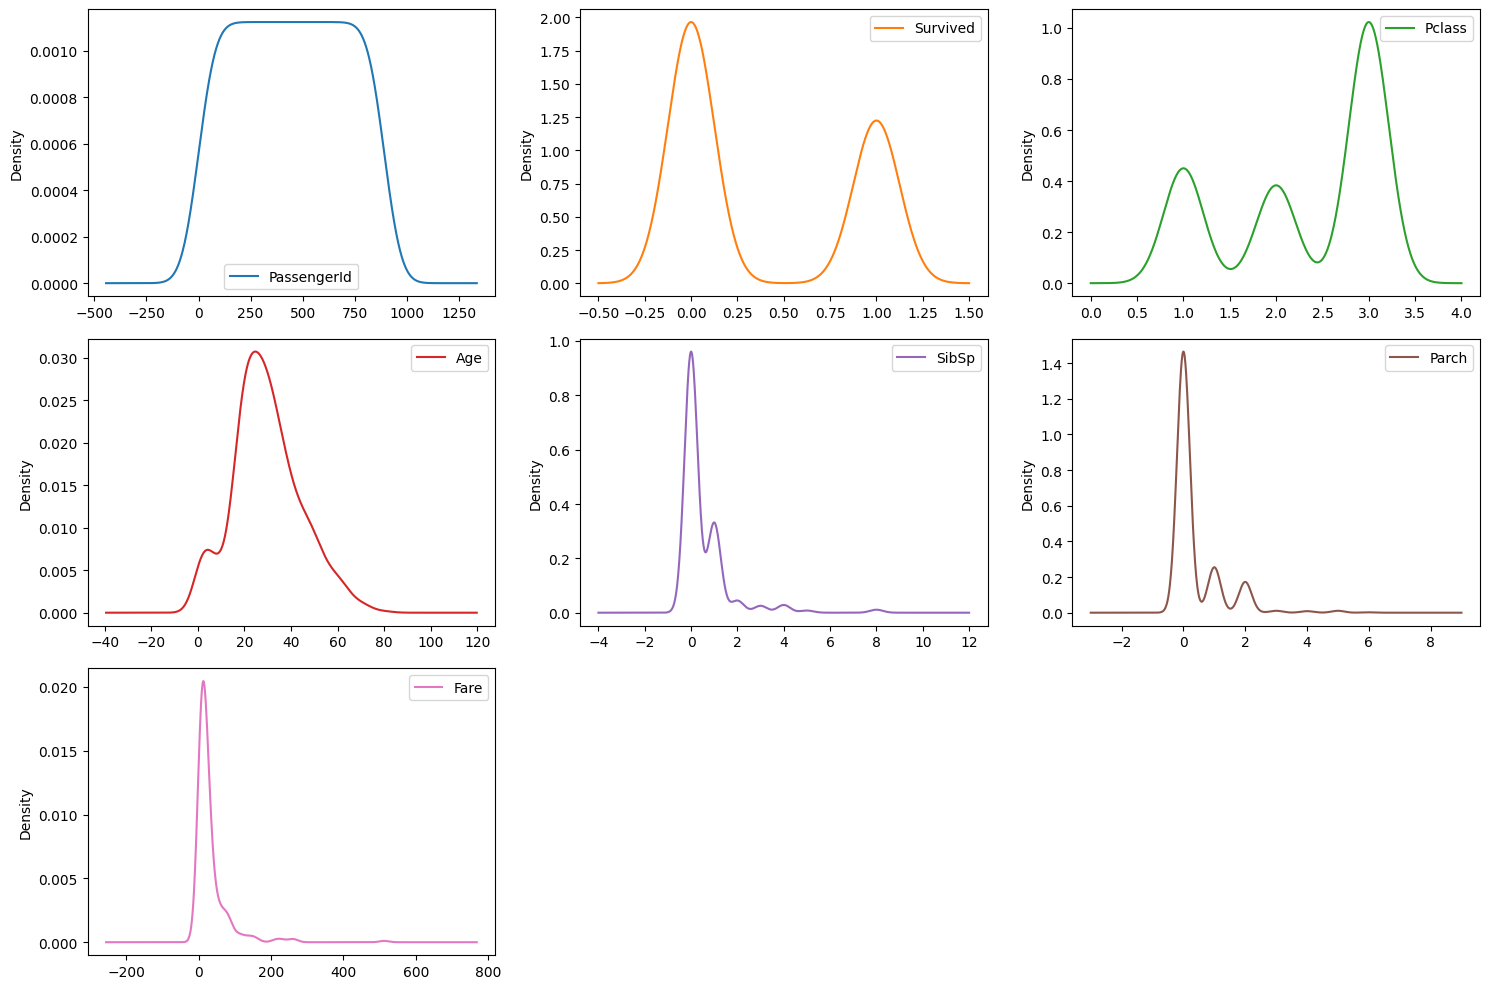

In [40]:
import matplotlib.pyplot as plt

# Select only numeric columns and plot them in a grid layout
df.select_dtypes(include=['number']).plot(
    kind='kde',
    subplots=True,
    layout=(-1, 3),  # Automatically determines rows, locks columns to 3
    figsize=(15, 10),
    sharex=False     # Allows individual columns to use their own x-axis scale
)

plt.tight_layout()

In [41]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [42]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [43]:
capital_gain_Q1 = X_train['Fare'].quantile(0.25)
capital_gain_Q3 = X_train['Fare'].quantile(0.75)

IQR = capital_gain_Q3 - capital_gain_Q1

minimum = max(0 , capital_gain_Q1 - 1.5 * IQR)
maximum = capital_gain_Q3 + 1.5 * IQR

X_train['Fare'] = X_train['Fare'].clip(minimum, maximum)
X_test['Fare'] = X_test['Fare'].clip(minimum, maximum)

In [44]:
capital_gain_Q1 = X_train['SibSp'].quantile(0.25)
capital_gain_Q3 = X_train['SibSp'].quantile(0.75)

IQR = capital_gain_Q3 - capital_gain_Q1

minimum = max(0 , capital_gain_Q1 - 1.5 * IQR)
maximum = capital_gain_Q3 + 1.5 * IQR

X_train['SibSp'] = X_train['SibSp'].clip(minimum, maximum)
X_test['SibSp'] = X_test['SibSp'].clip(minimum, maximum)

In [45]:
capital_gain_Q1 = X_train['Parch'].quantile(0.25)
capital_gain_Q3 = X_train['Parch'].quantile(0.75)

IQR = capital_gain_Q3 - capital_gain_Q1

minimum = max(0 , capital_gain_Q1 - 1.5 * IQR)
maximum = capital_gain_Q3 + 1.5 * IQR

X_train['Parch'] = X_train['Parch'].clip(minimum, maximum)
X_test['Parch'] = X_test['Parch'].clip(minimum, maximum)

In [46]:
#sex, pclass
one_hot_encoder = Pipeline(
    steps=[
        ('encoder',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'))
    ]
)

In [47]:
#age
missing_values_standard_scaler = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='mean')),
        ('scaler',StandardScaler())
    ]
)

In [48]:
from sklearn.preprocessing import RobustScaler

In [49]:
#fare, sibsp, parch
robust_scaler = Pipeline(
    steps=[
        ('scaler',RobustScaler())
    ]
)

In [50]:
#embarked
missing_values_one_hot_encoder = Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('encoder',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'))
    ]
)

In [55]:
preprocessor = ColumnTransformer(
    transformers=[
        ('missing_values_one_hot_encoder', missing_values_one_hot_encoder, ['Embarked']),
        ('one_hot_encoder',one_hot_encoder,['Sex', 'Pclass']),
        ('standard_scaler',missing_values_standard_scaler,['Age']),
        ('robust_scaler', robust_scaler, ['Fare', 'SibSp', 'Parch'])
    ],
    remainder='drop'
)
preprocessor

ColumnTransformer(transformers=[('missing_values_one_hot_encoder',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Embarked']),
                                ('one_hot_encoder',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Sex', 'Pclass']),
                                ('standard_scaler',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['Age']),
                                ('robust_scaler',
                                 Pipeline(steps=[('scaler', RobustScaler())]),
                                 ['Fare', 'SibSp', 'Parch'])])

In [56]:
results = []

In [58]:
model_1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=2, random_state = 42))
])

model_1.fit(X_train,y_train)

# training data accuracy
y_pred_train = model_1.predict(X_train)
train_accuracy = accuracy_score(y_train,y_pred_train)


# testing accuracy
y_pred = model_1.predict(X_test)

test_accuracy = accuracy_score(y_test,y_pred)

Training Accuracy: 0.8047752808988764
Testing Accuracy: 0.7597765363128491


In [59]:
model_10 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(max_depth=10, random_state = 42))
])

model_10.fit(X_train,y_train)

# training data accuracy
y_pred_train = model_10.predict(X_train)
train_accuracy_10 = accuracy_score(y_train,y_pred_train)


# testing accuracy
y_pred = model_10.predict(X_test)

test_accuracy_10 = accuracy_score(y_test,y_pred)

In [60]:
model_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state = 42))
])

model_rf.fit(X_train,y_train)

# training data accuracy
y_pred_train = model_rf.predict(X_train)
train_accuracy_rf = accuracy_score(y_train,y_pred_train)


# testing accuracy
y_pred = model_rf.predict(X_test)

test_accuracy_rf = accuracy_score(y_test,y_pred)

In [61]:
results.append({
    'Model': 'Decision Tree 2',
    'Train Accuracy': train_accuracy,
    'Test Accuracy': test_accuracy
})

In [62]:
results.append({
    'Model': 'Decision Tree 10',
    'Train Accuracy': train_accuracy_10,
    'Test Accuracy': test_accuracy_10
})

In [63]:
results.append({
    'Model': 'Random Forest 100 estimators',
    'Train Accuracy': train_accuracy_rf,
    'Test Accuracy': test_accuracy_rf
})

In [64]:
compare = pd.DataFrame(results)
print(compare)

                          Model  Train Accuracy  Test Accuracy
0               Decision Tree 2        1.000000       0.606250
1              Decision Tree 10        0.943820       0.798883
2  Random Forest 100 estimators        0.980337       0.815642


High Variance:Decision Tree 2

The Evidence: Train Accuracy is perfect (1.000000), but Test Accuracy drops significantly to 0.606250.

What it means: This large gap indicates severe overfitting. The model has completely memorized the training data but fails to generalize to unseen test data.

High Bias: None of these models

The Evidence: All three models achieve very high training accuracies (\(94\%\) to \(100\%\)).

What it means: High bias happens when a model is too simple and underfits, failing to learn the training patterns (resulting in poor training accuracy). None of these models suffer from that issue.

Balanced: Random Forest 100 estimators

The Evidence: It achieves the highest overall Test Accuracy (0.815642) while maintaining a high Train Accuracy (0.980337).

What it means: It offers the best trade-off. It learns the training data patterns well and successfully applies them to the test data, keeping the generalization gap small compared to Decision Tree 2.